La idea de esta sección es generar noticias falsas basandonos en las noticias del dataset

Lo primero que se ha hecho es una red GAN donde tenemos un generador que genera en base a ruido y un discriminador.

Se ha jugado con los parametros dentos del main, sin embargo en esta primera aproximación el mayor problema es que el modelo no es capaz de encontrar relación semantica entre las palabras.

La primera aproximación era aumentar las epochs, pero al aumentarlas lo unico que conseguimos son titulos mas breves hasta el punto de que devuelve titulos vacios, por lo que era necesario otra solución.

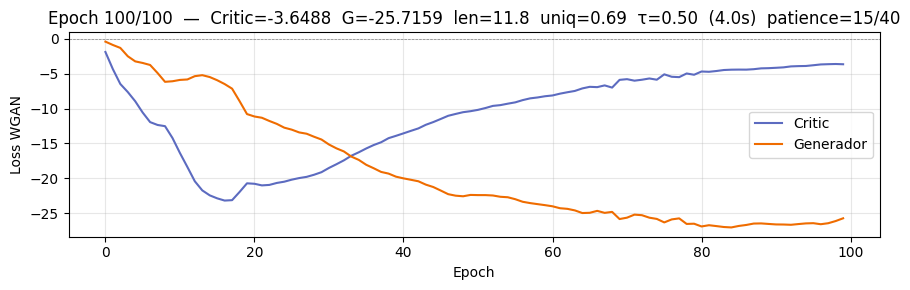


  ── Muestras generadas ──
  [1] children patricks offset avoid pride
  [2] discriminate speedier amid
  [3] us discriminate
  [4] rand house claytons pride recreational discriminate
  [5] imports whirlpools nra


  Entrenamiento completado.
Mounted at /content/drive


In [4]:
import re
import random
import argparse
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import RMSprop
from IPython.display import clear_output
import matplotlib.pyplot as plt
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

class Vocabulary:
    PAD, UNK, SOS, EOS = 0, 1, 2, 3
    PAD_TOKEN = "<PAD>"
    UNK_TOKEN = "<UNK>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"

    def __init__(self):
        self.word2idx = {
            self.PAD_TOKEN: self.PAD,
            self.UNK_TOKEN: self.UNK,
            self.SOS_TOKEN: self.SOS,
            self.EOS_TOKEN: self.EOS,
        }
        self.idx2word = {v: k for k, v in self.word2idx.items()}

    def build(self, texts, max_vocab=8_000, min_freq=1):
        from collections import Counter
        counter = Counter()
        for text in texts:
            counter.update(str(text).lower().split())
        for word, freq in counter.most_common(max_vocab):
            if freq < min_freq:
                break
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        print(f"[Vocab] {len(self.word2idx):,} tokens (de {len(counter):,} únicos)")

    def encode(self, text, max_len):
        tokens = str(text).lower().split()[:max_len - 2]
        ids = ([self.SOS]
               + [self.word2idx.get(t, self.UNK) for t in tokens]
               + [self.EOS])
        ids += [self.PAD] * (max_len - len(ids))
        return ids[:max_len]

    def decode(self, ids, skip_special=True):
        specials = {self.PAD, self.SOS, self.EOS}
        out = []
        for i in ids:
            if i == self.EOS:
                break
            if skip_special and i in specials:
                continue
            out.append(self.idx2word.get(i, self.UNK_TOKEN))
        return " ".join(out)

    def __len__(self):
        return len(self.word2idx)

class FakeNewsDataset(Dataset):

    def __init__(self, csv_path, vocab, max_len=15, max_samples=5000):
        self.vocab   = vocab
        self.max_len = max_len
        df = pd.read_csv(csv_path)
        raw = df["title"].dropna().astype(str).tolist()[:max_samples]
        self.texts = [self._clean(t) for t in raw]
        print(f"[Dataset] {len(self.texts):,} títulos cargados")
        print(f"[Dataset] Ejemplo: '{self.texts[0]}'")

    @staticmethod
    def _clean(text):
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.vocab.encode(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long)

class Generator(nn.Module):

    def __init__(self, vocab_size, embed_dim=100, hidden_dim=512,
                 seq_len=15, latent_dim=64, temperature=0.8):
        super().__init__()
        self.seq_len     = seq_len
        self.temperature = temperature
        self.hidden_dim  = hidden_dim
        self.vocab_size  = vocab_size

        self.z2h = nn.Linear(latent_dim, hidden_dim)
        self.z2c = nn.Linear(latent_dim, hidden_dim)

        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=1,
                            batch_first=True)
        self.proj = nn.Linear(hidden_dim, vocab_size)
        self.drop = nn.Dropout(0.3)

    def forward(self, z, hard=False):
        B = z.size(0)
        h = torch.tanh(self.z2h(z)).unsqueeze(0)
        c = torch.tanh(self.z2c(z)).unsqueeze(0)

        token = torch.full((B,), Vocabulary.SOS,
                           dtype=torch.long, device=z.device)
        all_soft_embs, all_ids = [], []

        for _ in range(self.seq_len):
            emb            = self.embed(token).unsqueeze(1)
            out, (h, c)    = self.lstm(emb, (h, c))
            logit          = self.proj(self.drop(out.squeeze(1)))
            soft           = F.gumbel_softmax(logit, tau=self.temperature, hard=hard)
            token          = soft.argmax(dim=-1)
            soft_emb       = soft @ self.embed.weight
            all_soft_embs.append(soft_emb)
            all_ids.append(token)

        soft_embs = torch.stack(all_soft_embs, dim=1)
        token_ids = torch.stack(all_ids,       dim=1)
        return soft_embs, token_ids

class Discriminator(nn.Module):

    def __init__(self, vocab_size, embed_dim=100, num_filters=256,
                 kernel_sizes=(2, 3, 4, 5)):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, num_filters, k),
                nn.LeakyReLU(0.2),
            ) for k in kernel_sizes
        ])
        self.drop = nn.Dropout(0.3)
        self.fc   = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, embs):
        x      = embs.transpose(1, 2)
        pooled = [conv(x).max(dim=-1).values for conv in self.convs]
        feat   = torch.cat(pooled, dim=1)
        return self.fc(self.drop(feat)).squeeze(-1)

class FakeNewsGANTrainer:

    def __init__(self, G, D, dataloader,
                 latent_dim=64, lr_g=3e-5, lr_d=3e-5,
                 n_critic=5, clip_value=0.02):
        self.G          = G.to(DEVICE)
        self.D          = D.to(DEVICE)
        self.dl         = dataloader
        self.ld         = latent_dim
        self.n_critic   = n_critic
        self.clip_value = clip_value

        self.opt_G = RMSprop(G.parameters(), lr=lr_g)
        self.opt_D = RMSprop(D.parameters(), lr=lr_d)

        self.temp_schedule = lambda ep, max_ep: max(
            0.5, 1.0 - 0.5 * (ep / max_ep)
        )
    def _z(self, n):
        return torch.randn(n, self.ld, device=DEVICE)

    def _real_embs(self, ids):
        with torch.no_grad():
            return self.G.embed(ids)

    def train_epoch(self, epoch, max_epochs):
        self.G.train()
        self.D.train()
        self.G.temperature = self.temp_schedule(epoch, max_epochs)
        d_losses, g_losses = [], []

        for real_ids in self.dl:
            real_ids  = real_ids.to(DEVICE)
            B         = real_ids.size(0)
            real_embs = self._real_embs(real_ids)

            for _ in range(self.n_critic):
                self.opt_D.zero_grad()
                d_real = self.D(real_embs.detach()).mean()
                with torch.no_grad():
                    fake_embs, _ = self.G(self._z(B))
                d_fake  = self.D(fake_embs).mean()
                loss_d  = -(d_real - d_fake)
                loss_d.backward()
                self.opt_D.step()
                for p in self.D.parameters():
                    p.data.clamp_(-self.clip_value, self.clip_value)
                d_losses.append(loss_d.item())

            self.opt_G.zero_grad()
            fake_embs, fake_ids = self.G(self._z(B))
            loss_wgan = -self.D(fake_embs).mean()
            lengths   = (fake_ids != Vocabulary.EOS).sum(dim=1).float()
            len_pen   = F.relu(torch.tensor(5.0, device=DEVICE) - lengths.mean())
            uniq = torch.tensor([
                len(set(s.tolist())) / max(len(s.tolist()), 1)
                for s in fake_ids
            ], device=DEVICE).mean()
            div_pen = F.relu(torch.tensor(0.4, device=DEVICE) - uniq)
            loss_g = loss_wgan + 2.0 * len_pen + 1.5 * div_pen
            loss_g.backward()
            self.opt_G.step()
            g_losses.append(loss_g.item())

        return np.mean(d_losses), np.mean(g_losses)

    def train(self, epochs, vocab, sample_every=10):
        print(f"\n{'═'*55}")
        print(f"  Fake News WGAN  |  {epochs} epochs  |  {DEVICE}")
        print(f"{'═'*55}\n")

        d_history, g_history = [], []
        best_g_loss          = float('inf')
        epochs_no_improve    = 0
        PATIENCE             = 40

        for ep in range(1, epochs + 1):
            t0      = time.time()
            ld, lg  = self.train_epoch(ep, epochs)
            elapsed = time.time() - t0

            d_history.append(ld)
            g_history.append(lg)

            with torch.no_grad():
                _, s_ids = self.G(self._z(32), hard=True)
                avg_len  = (s_ids != Vocabulary.EOS).sum(dim=1).float().mean().item()
                s_list   = s_ids.cpu().tolist()
                avg_uniq = sum(
                    len(set(s)) / max(len(s), 1)
                    for s in s_list
                ) / 32

            if lg < best_g_loss:
                best_g_loss       = lg
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(9, 3))
            ax.plot(d_history, label="Critic",    color="#5C6BC0")
            ax.plot(g_history, label="Generador", color="#EF6C00")
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss WGAN")
            ax.set_title(
                f"Epoch {ep}/{epochs}  —  "
                f"Critic={ld:.4f}  G={lg:.4f}  "
                f"len={avg_len:.1f}  uniq={avg_uniq:.2f}  "
                f"τ={self.G.temperature:.2f}  ({elapsed:.1f}s)  "
                f"patience={epochs_no_improve}/{PATIENCE}"
            )
            ax.legend()
            ax.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

            if ep % sample_every == 0:
                print("\n  ── Muestras generadas ──")
                texts = self.sample(vocab, n=5, verbose=False)
                for i, t in enumerate(texts, 1):
                    print(f"  [{i}] {t}")
                print()

            if epochs_no_improve >= PATIENCE:
                print(f"\n  [!] Early stopping en epoch {ep}")
                break

        print("\n  Entrenamiento completado.")

    @torch.no_grad()
    def sample(self, vocab, n=5, verbose=True):
        self.G.eval()
        _, ids = self.G(self._z(n), hard=True)
        texts  = [vocab.decode(seq.tolist()) for seq in ids.cpu()]
        self.G.train()
        if verbose:
            print("\n── Títulos generados ──")
            for i, t in enumerate(texts, 1):
                print(f"  [{i}] {t}")
        return texts

def main(args):
    set_seed(args.seed)

    vocab  = Vocabulary()
    tmp_ds = FakeNewsDataset(args.fake_csv, vocab,
                             max_len=args.max_len,
                             max_samples=args.max_samples)
    vocab.build(tmp_ds.texts, max_vocab=args.vocab_size, min_freq=args.min_freq)

    dataset = FakeNewsDataset(args.fake_csv, vocab,
                              max_len=args.max_len,
                              max_samples=args.max_samples)
    loader  = DataLoader(dataset, batch_size=args.batch_size,
                         shuffle=True, drop_last=True, num_workers=0)
    print(f"[DataLoader] {len(dataset):,} muestras | {len(loader)} batches")

    G = Generator(
        vocab_size            = len(vocab),
        embed_dim             = args.embed_dim,
        hidden_dim            = args.hidden_dim,
        seq_len               = args.max_len,
        latent_dim            = args.latent_dim,
        temperature           = 1.0
    )
    D = Discriminator(
        vocab_size            = len(vocab),
        embed_dim             = args.embed_dim,
        num_filters           = args.num_filters,
        kernel_sizes          = (2, 3, 4, 5),
    )

    trainer = FakeNewsGANTrainer(
        G, D, loader,
        latent_dim  = args.latent_dim,
        lr_g        = args.lr_g,
        lr_d        = args.lr_d,
        n_critic    = args.n_critic,
        clip_value  = args.clip_value)

    trainer.train(
        epochs       = args.epochs,
        vocab        = vocab,
        sample_every = args.sample_every)

    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    torch.save({
        "G":     G.state_dict(),
        "D":     D.state_dict(),
        "vocab": vocab.word2idx,
        "args":  vars(args),
    }, "/content/drive/MyDrive/fake_news_gan.pt")
    return trainer, vocab


if __name__ == "__main__":
    args = argparse.Namespace(
        fake_csv     = "/content/True.csv",
        max_len      = 20,
        max_samples  = 5000,
        vocab_size   = 8_000,
        min_freq     = 1,
        embed_dim    = 100,
        hidden_dim   = 512,
        latent_dim   = 64,
        num_filters  = 256,
        epochs       = 100,
        batch_size   = 256,
        lr_g         = 3e-5,
        lr_d         = 3e-5,
        n_critic     = 5,
        clip_value   = 0.02,
        sample_every = 10,
        seed         = 42,
    )

    trainer, vocab = main(args)

En esta iteración añadimos un modelo cambiamos el modo en el que el modelo genera noticias nuevas, ahora ingiere otras noticias y a apartir de esas crea nuevas.


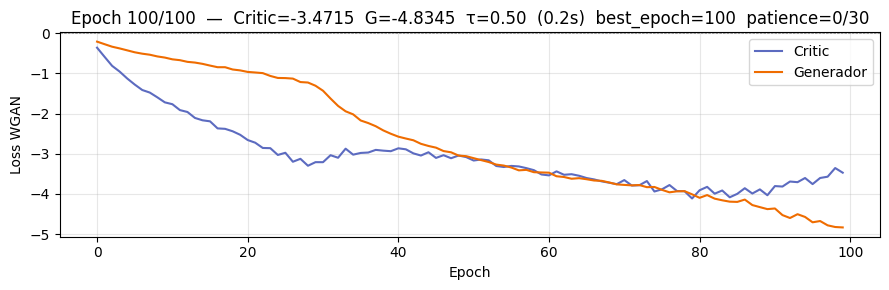


  ── Muestras generadas ──

── Debug entrada ──
  ids raw : [2, 1059, 4, 471, 189, 1291, 15, 278]
  decoded : 'facebook to overhaul political ads after threat of u.s. regulation'
  ids raw : [2, 1375, 4, 337, 8, 612, 1429, 1]
  decoded : 'sales to people on terrorism watch should be'
  ids raw : [2, 7, 13, 157, 393, 156, 71, 9]
  decoded : 'u.s. house democratic women seek probe of trump misconduct accusations'
  [1] harassment exxon lockheed islamist americans major later shift sentenced women's gunmen challenges later catalonia's life counter
  [2] expects comply protection spokeswoman wake voter front italian
  [3] greens

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  [✓] Modelo guardado en /content/drive/MyDrive/fake_news_gan.pt


In [15]:
import argparse
import random
import numpy as np
import pandas as pd
import torch
import re
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
from tqdm import tqdm
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from google.colab import drive
drive.mount('/content/drive')
output_csv = "/content/drive/MyDrive/noticias_generadas.csv"
save_path  = "/content/drive/MyDrive/fake_news_gan.pt"
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
def resume_from_checkpoint(checkpoint_path, trainer, vocab):
    ck = torch.load(checkpoint_path)
    trainer.G.load_state_dict(ck["G"])
    trainer.D.load_state_dict(ck["D"])
    vocab.word2idx = ck["vocab"]
    vocab.idx2word = {v: k for k, v in vocab.word2idx.items()}
    print(f"  [✓] Reanudando desde epoch {ck['epoch']}")
    return ck["epoch"], ck["d_history"], ck["g_history"]
class Vocabulary:
    PAD, UNK, SOS, EOS = 0, 1, 2, 3
    PAD_TOKEN = "<PAD>"
    UNK_TOKEN = "<UNK>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"
    def __init__(self):
        self.word2idx = {
            self.PAD_TOKEN: self.PAD,
            self.UNK_TOKEN: self.UNK,
            self.SOS_TOKEN: self.SOS,
            self.EOS_TOKEN: self.EOS,
        }
        self.idx2word = {v: k for k, v in self.word2idx.items()}
    def build(self, texts, max_vocab=15_000, min_freq=2):
        from collections import Counter
        counter = Counter()
        for text in texts:
            counter.update(str(text).lower().split())
        for word, freq in counter.most_common(max_vocab):
            if freq < min_freq:
                break
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        print(f"[Vocab] {len(self.word2idx):,} tokens "
              f"(de {len(counter):,} únicos en el corpus)")
    def encode(self, text, max_len):
        tokens = str(text).lower().split()[:max_len - 2]
        ids = [self.SOS] + [self.word2idx.get(t, self.UNK) for t in tokens] + [self.EOS]
        ids += [self.PAD] * (max_len - len(ids))
        return ids[:max_len]
    def decode(self, ids, skip_special=True):
        specials = {self.PAD, self.UNK, self.SOS, self.EOS}
        out = []
        for i in ids:
            if i == self.EOS:
                break
            if skip_special and i in specials:
                continue
            out.append(self.idx2word.get(i, self.UNK_TOKEN))
        return " ".join(out)
    def __len__(self):
        return len(self.word2idx)
class FakeNewsDataset(Dataset):
    def _clean(self, text):
        text = text.lower()
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    def __init__(self, csv_path: str, vocab: Vocabulary, max_len: int = 15):
        self.vocab   = vocab
        self.max_len = max_len

        df = pd.read_csv(csv_path)
        self.texts = [self._clean(t) for t in df["title"].dropna().astype(str).tolist()]
        print(f"[Dataset] {len(self.texts)} títulos cargados")
        print(f"[Dataset] Ejemplo: '{self.texts[0]}'")

    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        ids = self.vocab.encode(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long)
class Generator(nn.Module):
    """
    Generador condicional — en vez de partir de ruido puro,
    codifica un título real y genera una variación.
    Así el LSTM siempre tiene estructura lingüística de partida.
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=512,
                 seq_len=10, latent_dim=128, temperature=0.8):
        super().__init__()
        self.seq_len     = seq_len
        self.temperature = temperature
        self.hidden_dim  = hidden_dim
        self.vocab_size  = vocab_size
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(0.3)

        self.encoder = nn.LSTM(embed_dim, hidden_dim, num_layers=1,
                               batch_first=True)
        self.z_proj  = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(embed_dim, hidden_dim, num_layers=1,
                               batch_first=True)
        self.proj    = nn.Linear(hidden_dim, vocab_size)
    def forward(self, real_ids, z, hard=False):
        """
        real_ids : (B, seq_len)  — título real como condición
        z        : (B, latent)   — ruido para variar el output
        """
        B = real_ids.size(0)
        emb_real       = self.dropout(self.embed(real_ids))
        _, (h_enc, c_enc) = self.encoder(emb_real)
        z_proj = torch.tanh(self.z_proj(z)).unsqueeze(0)
        h = torch.tanh(h_enc * 0.8 + z_proj * 0.2)
        c = c_enc
        token = torch.full((B,), Vocabulary.SOS, dtype=torch.long,
                           device=real_ids.device)
        all_soft_embs, all_ids = [], []

        for _ in range(self.seq_len):
            emb            = self.embed(token).unsqueeze(1)
            out, (h, c)    = self.decoder(emb, (h, c))
            logit          = self.proj(self.dropout(out.squeeze(1)))
            soft           = F.gumbel_softmax(logit, tau=self.temperature,
                                              hard=hard)
            token          = soft.argmax(dim=-1)
            soft_emb       = soft @ self.embed.weight
            all_soft_embs.append(soft_emb)
            all_ids.append(token)
        soft_embs = torch.stack(all_soft_embs, dim=1)
        token_ids = torch.stack(all_ids,       dim=1)
        return soft_embs, token_ids
class Discriminator(nn.Module):
    """
    WGAN critic
    """
    def __init__(self, embed_dim=64, num_filters=128,
                 kernel_sizes=(2, 3, 4, 5)):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, num_filters, k),
                nn.LeakyReLU(0.2),
            )
            for k in kernel_sizes
        ])
        self.drop = nn.Dropout(0.3)
        self.fc   = nn.Linear(num_filters * len(kernel_sizes), 1)
    def forward(self, embs):
        x = embs.transpose(1, 2)
        pooled = [conv(x).max(dim=-1).values for conv in self.convs]
        feat = torch.cat(pooled, dim=1)
        return self.fc(self.drop(feat)).squeeze(-1)
class FakeNewsGANTrainer:
    def __init__(self, G, D, dataloader,
                 latent_dim=64, lr_g=1e-4, lr_d=1e-4,
                 n_critic=5, clip_value=0.03):
        self.G          = G.to(DEVICE)
        self.D          = D.to(DEVICE)
        self.dl         = dataloader
        self.ld         = latent_dim
        self.n_critic   = n_critic
        self.clip_value = clip_value
        self.opt_G = torch.optim.RMSprop(G.parameters(), lr=lr_g)
        self.opt_D = torch.optim.RMSprop(D.parameters(), lr=lr_d)

        self.temp_schedule = lambda ep, max_ep: max(
            0.5, 1.0 - 0.5 * (ep / max_ep)
        )
    def _z(self, n):
        return torch.randn(n, self.ld, device=DEVICE)
    def _real_embs(self, ids):
        with torch.no_grad():
            return self.G.embed(ids)
    def train_epoch(self, epoch, max_epochs):
      self.G.train()
      self.D.train()
      self.G.temperature = self.temp_schedule(epoch, max_epochs)

      d_losses, g_losses = [], []

      for real_ids in self.dl:
        real_ids  = real_ids.to(DEVICE)
        B         = real_ids.size(0)
        real_embs = self._real_embs(real_ids)
        for _ in range(self.n_critic):
            self.opt_D.zero_grad()
            d_real = self.D(real_embs.detach()).mean()
            with torch.no_grad():
                z = self._z(B)
                fake_embs, _ = self.G(real_ids, z)
            d_fake = self.D(fake_embs).mean()

            loss_d = -(d_real - d_fake)
            loss_d.backward()
            self.opt_D.step()

            for p in self.D.parameters():
                p.data.clamp_(-self.clip_value, self.clip_value)

            d_losses.append(loss_d.item())
        self.opt_G.zero_grad()
        z = self._z(B)
        fake_embs, fake_ids = self.G(real_ids, z)

        loss_wgan = -self.D(fake_embs).mean()
        lengths   = (fake_ids != Vocabulary.EOS).sum(dim=1).float()
        avg_len   = lengths.mean()
        min_len   = torch.tensor(5.0, device=DEVICE)
        len_pen   = F.relu(min_len - avg_len)
        unique_ratio = torch.tensor([
            len(set(s.tolist())) / max(len(s.tolist()), 1)
            for s in fake_ids
        ], device=DEVICE).mean()
        div_pen = F.relu(0.4 - unique_ratio)

        loss_g = loss_wgan + 2.0 * len_pen + 1.5 * div_pen
        loss_g.backward()
        self.opt_G.step()
        g_losses.append(loss_g.item())
        return np.mean(d_losses), np.mean(g_losses)
    def train(self, epochs, vocab, sample_every=10, start_epoch=0):

      print(f"\n{'═'*55}")
      print(f"  Fake News WGAN  |  {epochs} epochs  |  {DEVICE}")
      print(f"{'═'*55}\n")

      d_history, g_history = [], []
      best_g_loss = float('inf')
      epochs_without_improvement = 0
      PATIENCE = 30

      for ep in range(start_epoch + 1, epochs + 1):
        t0 = time.time()
        ld, lg = self.train_epoch(ep, epochs)
        elapsed = time.time() - t0

        d_history.append(ld)
        g_history.append(lg)
        if lg < best_g_loss:
            best_g_loss = lg
            epochs_without_improvement = 0
            torch.save({
                "G":     self.G.state_dict(),
                "D":     self.D.state_dict(),
                "vocab": vocab.word2idx,
                "epoch": ep,
            }, "/content/drive/MyDrive/fake_news_gan.pt")
        else:
            epochs_without_improvement += 1

        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 3))
        ax.plot(d_history, label="Critic",    color="#5C6BC0")
        ax.plot(g_history, label="Generador", color="#EF6C00")
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss WGAN")
        ax.set_title(f"Epoch {ep}/{epochs}  —  "
                     f"Critic={ld:.4f}  G={lg:.4f}  "
                     f"τ={self.G.temperature:.2f}  "
                     f"({elapsed:.1f}s)  "
                     f"best_epoch={ep - epochs_without_improvement}  "
                     f"patience={epochs_without_improvement}/{PATIENCE}")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        if ep % sample_every == 0:
            print("\n  ── Muestras generadas ──")
            texts = self.sample(vocab, self.dataset, n=3, verbose=False)
            for i, t in enumerate(texts, 1):
                print(f"  [{i}] {t}")
            print()
        if epochs_without_improvement >= PATIENCE:
            print(f"\n  [!] Early stopping en epoch {ep}")
            print(f"  [✓] Mejor modelo fue epoch {ep - PATIENCE}")
            break

    print("  Entrenamiento completado.\n")

    @torch.no_grad()
    def sample(self, vocab, dataset, n=5, verbose=True):
        self.G.eval()
        indices  = random.sample(range(len(dataset)), n)
        real_ids = torch.stack([dataset[i] for i in indices]).to(DEVICE)
        print("\n── Debug entrada ──")
        for i, ids in enumerate(real_ids):
            decoded = vocab.decode(ids.tolist())
            print(f"  ids raw : {ids[:8].tolist()}")
            print(f"  decoded : '{decoded}'")

        z       = self._z(n)
        _, ids  = self.G(real_ids, z, hard=True)
        texts   = [vocab.decode(seq.tolist()) for seq in ids.cpu()]

        if verbose:
            print("\n── Títulos generados ──")
            for i, t in enumerate(texts, 1):
                print(f"  [{i}] {t}")
        self.G.train()
        return texts
def main(args, resume_from=None):
    set_seed()
    vocab  = Vocabulary()
    tmp_ds = FakeNewsDataset(args.fake_csv, vocab, max_len=args.max_len)
    vocab.build(tmp_ds.texts, max_vocab=args.vocab_size, min_freq=args.min_freq)
    dataset = FakeNewsDataset(args.fake_csv, vocab, max_len=args.max_len)
    loader  = DataLoader(dataset, batch_size=args.batch_size,
                         shuffle=True, drop_last=True, num_workers=0)
    G = Generator(
        vocab_size  = len(vocab),
        embed_dim   = args.embed_dim,
        hidden_dim  = args.hidden_dim,
        seq_len     = args.max_len,
        latent_dim  = args.latent_dim,
        temperature = 1.0,)
    D = Discriminator(
        embed_dim    = args.embed_dim,
        num_filters  = args.num_filters,
        kernel_sizes = (2, 3, 4, 5),)
    start_epoch = 0
    if resume_from:
        ck = torch.load(resume_from, map_location=DEVICE)
        G.load_state_dict(ck["G"])
        D.load_state_dict(ck["D"])
        vocab.word2idx = ck["vocab"]
        vocab.idx2word = {v: k for k, v in vocab.word2idx.items()}
        start_epoch    = ck["epoch"]
        print(f"  [✓] Reanudando desde epoch {start_epoch}")
    trainer = FakeNewsGANTrainer(G, D, loader,
        latent_dim  = args.latent_dim,
        lr_g        = args.lr_g,
        lr_d        = args.lr_d,
        n_critic    = args.n_critic,
        clip_value  = 0.02,)
    trainer.dataset = dataset
    trainer.train(args.epochs, vocab,
                  sample_every = args.sample_every,
                  start_epoch  = start_epoch)

    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    save_path = "/content/drive/MyDrive/fake_news_gan.pt"
    torch.save({
        "G":     G.state_dict(),
        "D":     D.state_dict(),
        "vocab": vocab.word2idx,
        "args":  vars(args),
    }, save_path)
    print(f"  [✓] Modelo guardado en {save_path}")
    return trainer, vocab

def generate_from_checkpoint(checkpoint_path: str, n: int = 10):
    ck   = torch.load(checkpoint_path, map_location="cpu")
    saved_args = ck.get("args", {})

    vocab = Vocabulary()
    vocab.word2idx = ck["vocab"]
    vocab.idx2word = {v: k for k, v in vocab.word2idx.items()}

    G = Generator(
        vocab_size  = len(vocab),
        embed_dim   = saved_args.get("embed_dim",  128),
        hidden_dim  = saved_args.get("hidden_dim", 512),
        seq_len     = saved_args.get("max_len",     60),
        latent_dim  = saved_args.get("latent_dim", 128),)
    G.load_state_dict(ck["G"])
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, saved_args.get("latent_dim", 128))
        _, ids = G(z, hard=True)
    print(f"\n── {n} noticias falsas generadas ──")
    for i, seq in enumerate(ids.tolist(), 1):
        print(f"[{i:2d}] {vocab.decode(seq)}")
if __name__ == "__main__":
    import argparse
    args = argparse.Namespace(
    fake_csv     = "/content/True.csv",
    max_len      = 20,
    vocab_size   = 3_000,
    min_freq     = 3,
    embed_dim    = 64,
    hidden_dim  = 512,
    latent_dim  = 128,
    num_filters = 256,
    epochs       = 100,
    batch_size   = 256,
    lr_g         = 3e-5,
    lr_d         = 3e-5,
    n_critic     = 5,
    sample_every = 10,
    generate     = 20,
    output_csv   = "/content/noticias_generadas.csv",
    save_path    = "/content/fake_news_gan.pt",
)
    RESUME     = False

    if RESUME:
        trainer, vocab=main(args, resume_from=CHECKPOINT)
    else:
        trainer, vocab=main(args, resume_from=None)


In [16]:
import torch
import random

ck = torch.load("/content/drive/MyDrive/fake_news_gan.pt", map_location="cpu")
vocab = Vocabulary()
vocab.word2idx = ck["vocab"]
vocab.idx2word = {v: k for k, v in vocab.word2idx.items()}
G = Generator(
    vocab_size  = len(vocab),
    embed_dim   = args.embed_dim,
    hidden_dim  = args.hidden_dim,
    seq_len     = args.max_len,
    latent_dim  = args.latent_dim,
    temperature = 0.2,
)
dataset = FakeNewsDataset(args.fake_csv, vocab, max_len=args.max_len)
G.load_state_dict(ck["G"])
G.eval()
indices  = random.sample(range(len(dataset)), 5)
real_ids = torch.stack([dataset[i] for i in indices])

with torch.no_grad():
    z = torch.randn(5, args.latent_dim)
    _, ids = G(real_ids, z, hard=True)

print("── Títulos generados ──")
for i, seq in enumerate(ids.tolist(), 1):
    original = vocab.decode(dataset[indices[i-1]].tolist())
    generado = vocab.decode(seq)
    print(f"[{i}] original : {original}")
    print(f"     generado : {generado}\n")

[Dataset] 21417 títulos cargados
[Dataset] Ejemplo: 'as u.s. budget fight looms, republicans flip their fiscal script'
── Títulos generados ──
[1] original : trump says up will pay for budget fox
     generado : development met race protection deputy 'dreamer' grave colombia ugandan

[2] original : iran warns it would increase missile range if by europe
     generado : migrant raises

[3] original : drug lawmakers clash ahead of congressional hearing
     generado : earthquake later deal life very backlash deals don't pyongyang niger cleveland candidate

[4] original : illinois to sell but cannot all the
     generado : approve colombia says well

[5] original : no. 2 senate republican says senate to probe trump's wiretap claims
     generado : commitment long to claims pledges italian we raises easing candidate britain, men considering proposals army home hike embrace



Como se puede apreciar las respuestas mejoran bastante respecto al modelo anterior pero aun hay rango de mejora y para ello usamos un modelo pre entrenado de embeddings llamado GloVe.

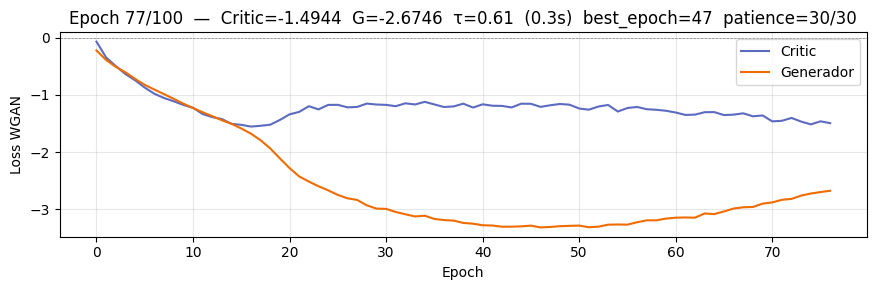


  [!] Early stopping en epoch 77
  [✓] Mejor modelo fue epoch 47
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  [✓] Modelo guardado en /content/drive/MyDrive/fake_news_gan.pt


In [11]:
!pip install -q gensim
import gensim.downloader as api
import argparse
import random
import numpy as np
import pandas as pd
import torch
import re
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from tqdm import tqdm
from collections import Counter
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from google.colab import drive
drive.mount('/content/drive')
output_csv = "/content/drive/MyDrive/noticias_generadas.csv"
save_path  = "/content/drive/MyDrive/fake_news_gan.pt"
glove = api.load("glove-wiki-gigaword-100")
def build_embedding_matrix(vocab, glove, embed_dim=100):
    matrix = torch.zeros(len(vocab), embed_dim)
    found, notfound = 0, 0
    for word, idx in vocab.word2idx.items():
        if word in glove:
            matrix[idx] = torch.tensor(glove[word])
            found += 1
        else:
            matrix[idx] = torch.randn(embed_dim) * 0.1
            notfound += 1
    return matrix
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def resume_from_checkpoint(checkpoint_path, trainer, vocab):
    ck = torch.load(checkpoint_path)
    trainer.G.load_state_dict(ck["G"])
    trainer.D.load_state_dict(ck["D"])
    vocab.word2idx = ck["vocab"]
    vocab.idx2word = {v: k for k, v in vocab.word2idx.items()}
    print(f"  [✓] Reanudando desde epoch {ck['epoch']}")
    return ck["epoch"], ck["d_history"], ck["g_history"]
class Vocabulary:
    PAD, UNK, SOS, EOS = 0, 1, 2, 3
    PAD_TOKEN = "<PAD>"
    UNK_TOKEN = "<UNK>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"
    def __init__(self):
        self.word2idx = {
            self.PAD_TOKEN: self.PAD,
            self.UNK_TOKEN: self.UNK,
            self.SOS_TOKEN: self.SOS,
            self.EOS_TOKEN: self.EOS,
        }
        self.idx2word = {v: k for k, v in self.word2idx.items()}
    def build(self, texts, max_vocab=15_000, min_freq=2):

        counter = Counter()
        for text in texts:
            counter.update(str(text).lower().split())
        for word, freq in counter.most_common(max_vocab):
            if freq < min_freq:
                break
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        print(f"[Vocab] {len(self.word2idx):,} tokens "
              f"(de {len(counter):,} únicos en el corpus)")
    def encode(self, text, max_len):
        tokens = str(text).lower().split()[:max_len - 2]
        ids = [self.SOS] + [self.word2idx.get(t, self.UNK) for t in tokens] + [self.EOS]
        ids += [self.PAD] * (max_len - len(ids))
        return ids[:max_len]
    def decode(self, ids, skip_special=True):
        specials = {self.PAD, self.UNK, self.SOS, self.EOS}
        out = []
        for i in ids:
            if i == self.EOS:
                break
            if skip_special and i in specials:
                continue
            out.append(self.idx2word.get(i, self.UNK_TOKEN))
        return " ".join(out)
    def __len__(self):
        return len(self.word2idx)
class FakeNewsDataset(Dataset):
    def _clean(self, text):
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    def __init__(self, csv_path: str, vocab: Vocabulary, max_len: int = 15):
        self.vocab   = vocab
        self.max_len = max_len
        df = pd.read_csv(csv_path)
        self.texts = [self._clean(t) for t in df["title"].dropna().astype(str).tolist()]
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        ids = self.vocab.encode(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long)
class Generator(nn.Module):
    """
    Generador condicional — en vez de partir de ruido puro,
    codifica un título real y genera una variación.
    """
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=512,
             seq_len=15, latent_dim=64, temperature=0.8,
             pretrained_embeddings=None):
        super().__init__()
        self.seq_len     = seq_len
        self.temperature = temperature
        self.hidden_dim  = hidden_dim
        self.vocab_size  = vocab_size

        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embed.weight.data.copy_(pretrained_embeddings)
            self.embed.weight.requires_grad = True
            print("✓ Embeddings preentrenados cargados en Generador")

        self.z_proj  = nn.Linear(latent_dim, hidden_dim)
        self.encoder = nn.LSTM(embed_dim, hidden_dim, num_layers=1,
                              batch_first=True)
        self.decoder = nn.LSTM(embed_dim, hidden_dim, num_layers=1,
                              batch_first=True)
        self.proj    = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(0.3)
    def forward(self, real_ids, z, hard=False):
        """
        real_ids : (B, seq_len)  — título real como condición
        z        : (B, latent)   — ruido para variar el output
        """
        B = real_ids.size(0)
        emb_real       = self.dropout(self.embed(real_ids))
        _, (h_enc, c_enc) = self.encoder(emb_real)
        z_proj = torch.tanh(self.z_proj(z)).unsqueeze(0)
        h = torch.tanh(h_enc * 0.8 + z_proj * 0.2)
        c = c_enc
        token = torch.full((B,), Vocabulary.SOS, dtype=torch.long,
                           device=real_ids.device)
        all_soft_embs, all_ids = [], []
        for _ in range(self.seq_len):
            emb            = self.embed(token).unsqueeze(1)
            out, (h, c)    = self.decoder(emb, (h, c))
            logit          = self.proj(self.dropout(out.squeeze(1)))
            soft           = F.gumbel_softmax(logit, tau=self.temperature,
                                              hard=hard)
            token          = soft.argmax(dim=-1)
            soft_emb       = soft @ self.embed.weight
            all_soft_embs.append(soft_emb)
            all_ids.append(token)
        soft_embs = torch.stack(all_soft_embs, dim=1)
        token_ids = torch.stack(all_ids,       dim=1)
        return soft_embs, token_ids
class Discriminator(nn.Module):
    """
    WGAN critic
    """
    def __init__(self, vocab_size, embed_dim=100, num_filters=256,
             kernel_sizes=(2,3,4,5), pretrained_embeddings=None):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embed.weight.data.copy_(pretrained_embeddings)
            self.embed.weight.requires_grad = True
            print("✓ Embeddings preentrenados cargados en Discriminador")
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, num_filters, k),
                nn.LeakyReLU(0.2),
            )
            for k in kernel_sizes
        ])
        self.drop = nn.Dropout(0.3)
        self.fc   = nn.Linear(num_filters * len(kernel_sizes), 1)
    def forward(self, embs):
        x = embs.transpose(1, 2)
        pooled = [conv(x).max(dim=-1).values for conv in self.convs]
        feat = torch.cat(pooled, dim=1)
        return self.fc(self.drop(feat)).squeeze(-1)
class FakeNewsGANTrainer:
    def __init__(self, G, D, dataloader,
                 latent_dim=64, lr_g=1e-4, lr_d=1e-4,
                 n_critic=5, clip_value=0.03):
        self.G          = G.to(DEVICE)
        self.D          = D.to(DEVICE)
        self.dl         = dataloader
        self.ld         = latent_dim
        self.n_critic   = n_critic
        self.clip_value = clip_value
        self.opt_G = torch.optim.RMSprop(G.parameters(), lr=lr_g)
        self.opt_D = torch.optim.RMSprop(D.parameters(), lr=lr_d)

        self.temp_schedule = lambda ep, max_ep: max(
            0.5, 1.0 - 0.5 * (ep / max_ep)
        )
    def _z(self, n):
        return torch.randn(n, self.ld, device=DEVICE)
    def _real_embs(self, ids):
        with torch.no_grad():
            return self.G.embed(ids)
    def train_epoch(self, epoch, max_epochs):
      self.G.train()
      self.D.train()
      self.G.temperature = self.temp_schedule(epoch, max_epochs)

      d_losses, g_losses = [], []

      for real_ids in self.dl:
        real_ids  = real_ids.to(DEVICE)
        B         = real_ids.size(0)
        real_embs = self._real_embs(real_ids)
        for _ in range(self.n_critic):
            self.opt_D.zero_grad()
            d_real = self.D(real_embs.detach()).mean()
            with torch.no_grad():
                z = self._z(B)
                fake_embs, _ = self.G(real_ids, z)
            d_fake = self.D(fake_embs).mean()

            loss_d = -(d_real - d_fake)
            loss_d.backward()
            self.opt_D.step()

            for p in self.D.parameters():
                p.data.clamp_(-self.clip_value, self.clip_value)

            d_losses.append(loss_d.item())
        self.opt_G.zero_grad()
        z = self._z(B)
        fake_embs, fake_ids = self.G(real_ids, z)

        loss_wgan = -self.D(fake_embs).mean()

        # Penalización por brevedad y diversidad
        lengths   = (fake_ids != Vocabulary.EOS).sum(dim=1).float()
        avg_len   = lengths.mean()
        min_len   = torch.tensor(5.0, device=DEVICE)
        len_pen   = F.relu(min_len - avg_len)
        unique_ratio = torch.tensor([
            len(set(s.tolist())) / max(len(s.tolist()), 1)
            for s in fake_ids
        ], device=DEVICE).mean()
        div_pen = F.relu(0.4 - unique_ratio)

        loss_g = loss_wgan + 2.0 * len_pen + 1.5 * div_pen
        loss_g.backward()
        self.opt_G.step()
        g_losses.append(loss_g.item())
        return np.mean(d_losses), np.mean(g_losses)
    def train(self, epochs, vocab, sample_every=10, start_epoch=0):
      d_history, g_history = [], []
      best_g_loss = float('inf')
      epochs_without_improvement = 0
      PATIENCE = 30

      for ep in range(start_epoch + 1, epochs + 1):
        t0 = time.time()
        ld, lg = self.train_epoch(ep, epochs)
        elapsed = time.time() - t0
        d_history.append(ld)
        g_history.append(lg)
        if lg < best_g_loss:
            best_g_loss = lg
            epochs_without_improvement = 0
            torch.save({
                "G":     self.G.state_dict(),
                "D":     self.D.state_dict(),
                "vocab": vocab.word2idx,
                "epoch": ep,
            }, "/content/drive/MyDrive/best_model.pt")
        else:
            epochs_without_improvement += 1
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 3))
        ax.plot(d_history, label="Critic",    color="#5C6BC0")
        ax.plot(g_history, label="Generador", color="#EF6C00")
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss WGAN")
        ax.set_title(f"Epoch {ep}/{epochs}  —  "
                     f"Critic={ld:.4f}  G={lg:.4f}  "
                     f"τ={self.G.temperature:.2f}  "
                     f"({elapsed:.1f}s)  "
                     f"best_epoch={ep - epochs_without_improvement}  "
                     f"patience={epochs_without_improvement}/{PATIENCE}")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        if ep % sample_every == 0:
            print("\n  ── Muestras generadas ──")
            texts = self.sample(vocab, self.dataset, n=3, verbose=False)
            for i, t in enumerate(texts, 1):
                print(f"  [{i}] {t}")
            print()
        if epochs_without_improvement >= PATIENCE:
            print(f"\n  [!] Early stopping en epoch {ep}")
            print(f"  [✓] Mejor modelo fue epoch {ep - PATIENCE}")
            break

    print("  Entrenamiento completado.\n")
    @torch.no_grad()
    def sample(self, vocab, dataset, n=5, verbose=True):
        self.G.eval()
        indices  = random.sample(range(len(dataset)), n)
        real_ids = torch.stack([dataset[i] for i in indices]).to(DEVICE)
        print("\n── Debug entrada ──")
        for i, ids in enumerate(real_ids):
            decoded = vocab.decode(ids.tolist())
            print(f"  ids raw : {ids[:8].tolist()}")
            print(f"  decoded : '{decoded}'")

        z       = self._z(n)
        _, ids  = self.G(real_ids, z, hard=True)
        texts   = [vocab.decode(seq.tolist()) for seq in ids.cpu()]

        if verbose:
            print("\n── Títulos generados ──")
            for i, t in enumerate(texts, 1):
                print(f"  [{i}] {t}")
        self.G.train()
        return texts
def main(args, resume_from=None):
    set_seed()
    vocab  = Vocabulary()
    tmp_ds = FakeNewsDataset(args.fake_csv, vocab, max_len=args.max_len)
    vocab.build(tmp_ds.texts, max_vocab=args.vocab_size, min_freq=args.min_freq)
    dataset = FakeNewsDataset(args.fake_csv, vocab, max_len=args.max_len)
    loader  = DataLoader(dataset, batch_size=args.batch_size,
                         shuffle=True, drop_last=True, num_workers=0)
    embedding_matrix = build_embedding_matrix(vocab, glove, embed_dim=100)
    G = Generator(
        vocab_size             = len(vocab),
        embed_dim              = 100,
        hidden_dim             = 512,
        seq_len                = args.max_len,
        latent_dim             = args.latent_dim,
        temperature            = 1.0,
        pretrained_embeddings  = embedding_matrix,
    )
    D = Discriminator(
        vocab_size            = len(vocab),
        embed_dim             = 100,
        num_filters           = 256,
        kernel_sizes          = (2, 3, 4, 5),
        pretrained_embeddings = embedding_matrix,
    )
    start_epoch = 0
    if resume_from:
        ck = torch.load(resume_from, map_location=DEVICE)
        G.load_state_dict(ck["G"])
        D.load_state_dict(ck["D"])
        vocab.word2idx = ck["vocab"]
        vocab.idx2word = {v: k for k, v in vocab.word2idx.items()}
        start_epoch    = ck["epoch"]
        print(f"  [✓] Reanudando desde epoch {start_epoch}")


    trainer = FakeNewsGANTrainer(G, D, loader,
        latent_dim  = args.latent_dim,
        lr_g        = args.lr_g,
        lr_d        = args.lr_d,
        n_critic    = args.n_critic,
        clip_value  = 0.02,)
    trainer.dataset = dataset
    trainer.train(args.epochs, vocab,
                  sample_every = args.sample_every,
                  start_epoch  = start_epoch)
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    save_path = "/content/drive/MyDrive/fake_news_gan.pt"
    torch.save({
        "G":     G.state_dict(),
        "D":     D.state_dict(),
        "vocab": vocab.word2idx,
        "args":  vars(args),
    }, save_path)
    print(f"  [✓] Modelo guardado en {save_path}")
    return trainer, vocab

def generate_from_checkpoint(checkpoint_path: str, n: int = 10):
    ck   = torch.load(checkpoint_path, map_location="cpu")
    saved_args = ck.get("args", {})

    vocab = Vocabulary()
    vocab.word2idx = ck["vocab"]
    vocab.idx2word = {v: k for k, v in vocab.word2idx.items()}

    G = Generator(
        vocab_size  = len(vocab),
        embed_dim   = saved_args.get("embed_dim",  128),
        hidden_dim  = saved_args.get("hidden_dim", 512),
        seq_len     = saved_args.get("max_len",     60),
        latent_dim  = saved_args.get("latent_dim", 128),)
    G.load_state_dict(ck["G"])
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, saved_args.get("latent_dim", 128))
        _, ids = G(z, hard=True)
    print(f"\n── {n} noticias falsas generadas ──")
    for i, seq in enumerate(ids.tolist(), 1):
        print(f"[{i:2d}] {vocab.decode(seq)}")
if __name__ == "__main__":
    import argparse
    args = argparse.Namespace(
    fake_csv     = "/content/True.csv",
    max_len      = 15,
    vocab_size   = 8_000,
    min_freq     = 1,
    embed_dim    = 100,
    hidden_dim   = 512,
    latent_dim   = 64,
    num_filters  = 256,
    epochs       = 100,
    batch_size   = 256,
    lr_g         = 3e-5,
    lr_d         = 3e-5,
    n_critic     = 5,
    sample_every = 10,
    seed         = 42,
    generate     = 20,
    output_csv   = "/content/noticias_generadas.csv",
    save_path    = "/content/fake_news_gan.pt",
)
    RESUME     = False

    if RESUME:
        trainer, vocab=main(args, resume_from=CHECKPOINT)
    else:
        trainer, vocab=main(args, resume_from=None)


In [14]:
import torch
import random

ck = torch.load("/content/drive/MyDrive/fake_news_gan.pt", map_location="cpu")
vocab = Vocabulary()
vocab.word2idx = ck["vocab"]
vocab.idx2word = {v: k for k, v in vocab.word2idx.items()}
G = Generator(
    vocab_size  = len(vocab),
    embed_dim   = args.embed_dim,
    hidden_dim  = args.hidden_dim,
    seq_len     = args.max_len,
    latent_dim  = args.latent_dim,
    temperature = 0.2,
)
dataset = FakeNewsDataset(args.fake_csv, vocab, max_len=args.max_len)
G.load_state_dict(ck["G"])
G.eval()
indices  = random.sample(range(len(dataset)), 5)
real_ids = torch.stack([dataset[i] for i in indices])

with torch.no_grad():
    z = torch.randn(5, args.latent_dim)
    _, ids = G(real_ids, z, hard=True)

print("── Títulos generados ──")
for i, seq in enumerate(ids.tolist(), 1):
    original = vocab.decode(dataset[indices[i-1]].tolist())
    generado = vocab.decode(seq)
    print(f"[{i}] original : {original}")
    print(f"     generado : {generado}\n")

── Títulos generados ──
[1] original : iran warns it would increase missile range if threatened by europe
     generado : bathrooms billion defeat republicans like billion resolve russia like russia leader ministers parliament laws would

[2] original : drug exec shkreli lawmakers clash ahead of congressional hearing
     generado : xl time buster rebels act foreign that try or negotiator putin negotiator try comments research

[3] original : illinois to sell bonds but cannot tap all the proceeds
     generado : bush a people a ouster international college address israel on could raised oil 7 you

[4] original : no 2 senate republican says senate to probe trumps wiretap claims
     generado : holocaust hamas senators supreme protection was a territory position has missile change ongoing martial leader

[5] original : trump turns to washington lawyer to legal ethics issues
     generado : insult with thursday monday forces tass expected out campaign report out missile road league who



Las respuestas mejoran pero siguen sin ser creibles en la mayoria de casos, por eso probamos con modelos mas fuertes como los transformers, en este caso basta con usar GPT2

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from transformers import GPT2LMHeadModel, GPT2Tokenizer, Trainer, TrainingArguments
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
df = pd.read_csv("/content/True.csv")
titles = df["title"].dropna().astype(str).tolist()
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
model = GPT2LMHeadModel.from_pretrained("gpt2")

class TitleDataset(Dataset):
    def __init__(self, titles, tokenizer, max_len=32):
        self.examples = []
        for title in titles:
            enc = tokenizer(
                title,
                max_length     = max_len,
                truncation     = True,
                padding        = "max_length",
                return_tensors = "pt",
            )
            self.examples.append(enc["input_ids"].squeeze())

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ids = self.examples[idx]
        return {"input_ids": ids, "labels": ids.clone()}

dataset = TitleDataset(titles, tokenizer, max_len=32)
training_args = TrainingArguments(
    output_dir                  = "/content/gpt2_fakenews",
    num_train_epochs            = 10,
    per_device_train_batch_size = 32,
    save_steps                  = 200,
    logging_steps               = 50,
    prediction_loss_only        = True,
    fp16                        = torch.cuda.is_available(),)
trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = dataset,
)
trainer.train()
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
model.save_pretrained("/content/drive/MyDrive/gpt2_fakenews")
tokenizer.save_pretrained("/content/drive/MyDrive/gpt2_fakenews")
model.eval()
prompts = ["Trump", "White House", "Russia", "BREAKING", "Exclusive"]
print("\n── Títulos generados ──")
for prompt in prompts:
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    output = model.generate(
        input_ids,
        max_length           = 20,
        num_return_sequences = 3,
        temperature          = 0.9,
        top_k                = 50,
        top_p                = 0.95,
        do_sample            = True,
        pad_token_id         = tokenizer.eos_token_id,
    )
    print(f"\n  Prompt: '{prompt}'")
    for i, out in enumerate(output, 1):
        print(f"  [{i}] {tokenizer.decode(out, skip_special_tokens=True)}")

✓ 21417 títulos cargados


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Dataset: 21417 títulos


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Entrenamiento completado


KeyboardInterrupt: 

In [18]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model     = GPT2LMHeadModel.from_pretrained("/content/drive/MyDrive/gpt2_fakenews")
tokenizer = GPT2Tokenizer.from_pretrained("/content/drive/MyDrive/gpt2_fakenews")
model.eval()

prompts = ["Trump", "White House", "Russia", "BREAKING", "Exclusive","Justin","In 2017","Jews"]
print("\n── Títulos generados ──")
for prompt in prompts:
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(model.device)
    output = model.generate(
        input_ids,
        max_length           = 20,
        num_return_sequences = 3,
        temperature          = 0.9,
        top_k                = 50,
        top_p                = 0.95,
        do_sample            = True,
        pad_token_id         = tokenizer.eos_token_id,
    )
    print(f"\n  Prompt: '{prompt}'")
    for i, out in enumerate(output, 1):
        print(f"  [{i}] {tokenizer.decode(out, skip_special_tokens=True)}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


── Títulos generados ──

  Prompt: 'Trump'
  [1] Trump says he hopes U.S. can 'smarter' deal with North Korea
  [2] Trump says foreign policy won't have global impact
  [3] Trump to give first order on regulations on Wednesday, reversing Obama decision

  Prompt: 'White House'
  [1] White House says no firm date for Obamacare replacement
  [2] White House names lobbyist as acting CFTC commissioner
  [3] White House says Trump has 'constructive' phone call with Mexican leader

  Prompt: 'Russia'
  [1] Russia accuses U.S. of trying to recruit 'new generation' of hackers: agencies
  [2] Russia's Lavrov: U.S. to 'act quickly' to end Iran nuclear deal
  [3] Russia's Lavrov, Turkey's Erdogan discuss Syria, Iraq, Syria on sidelines of G20 summit

  Prompt: 'BREAKING'
  [1] BREAKING: Saudi-led coalition strikes Yemen at 'terrible prices'
  [2] BREAKING: Clinton campaign manager who met Russian lawyer gets subpoena
  [3] BREAKING: FBI probing possible Russian hacking of Democratic National Com

Usando transformers se resuelve el gran problema semantico, y tampoco hace falta usar muchos datos para el entrenamiento ni muchas epoch en nuestro caso ha sido suficiente con 10.
